<a href="https://colab.research.google.com/github/nfcr7/TP1/blob/main/TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator #there was an old version of the image genration and gemini gave me the new import
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:

img_width, img_height = 224, 224 #this one is for the redimension of the image .
train_data_dir = '/content/drive/MyDrive/images/train'
validation_data_dir = '/content/drive/MyDrive/images/test'

nb_train_samples = 400 # that the number of image in training well it already cleared by the name
nb_validation_samples = 100 # same for test
epochs = 15 # 15 times mean 15 time through the data set
batch_size = 16 #16 image each itteration
num_filters = 8 #number of convolutionnelle layers
filter_size = 3 #size of those layers


if K.image_data_format() == 'channels_first':
  input_shape = (3, img_width, img_height)
else:
  input_shape = (img_width, img_height, 3)

**Data preprocessing :**

In [ ]:
#this one work like data preprocessing but for image so they would be the same size same zoom all horizontal
train_datagen = ImageDataGenerator(
rescale = 1. / 255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1. / 255)
train_generator = train_datagen.flow_from_directory(train_data_dir,

target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')
validation_generator = test_datagen.flow_from_directory(

validation_data_dir,
target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


**CNN architecture :**

In [ ]:
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape = input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


**Training** :

In [ ]:
model.compile(loss ='binary_crossentropy',
optimizer ='rmsprop',

metrics =['accuracy'])
history=model.fit(train_generator,
 steps_per_epoch = nb_train_samples // batch_size,
 epochs = epochs, validation_data = validation_generator,
 validation_steps = nb_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 882ms/step - accuracy: 0.6150 - loss: 4.3122 - val_accuracy: 0.8542 - val_loss: 0.3526
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 656ms/step - accuracy: 0.7925 - loss: 0.5805 - val_accuracy: 0.9167 - val_loss: 0.2907
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 865ms/step - accuracy: 0.8025 - loss: 0.4962 - val_accuracy: 0.9062 - val_loss: 0.4091
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 778ms/step - accuracy: 0.8075 - loss: 0.4624 - val_accuracy: 0.6667 - val_loss: 0.7937
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 566ms/step - accuracy: 0.8200 - loss: 0.4293 - val_accuracy: 0.8750 - val_loss: 0.3654
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 583ms/step - accuracy: 0.8525 - loss: 0.4492 - val_accuracy: 0.8229 - val_loss: 0.4045
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 718ms/step - accuracy: 0.8950 - loss: 0.2831 - val_accuracy: 0.8333 - val_loss: 0.3428
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 682ms/step - accuracy: 0.8500 - loss: 0.3522 - val_accu

**Plot section** :

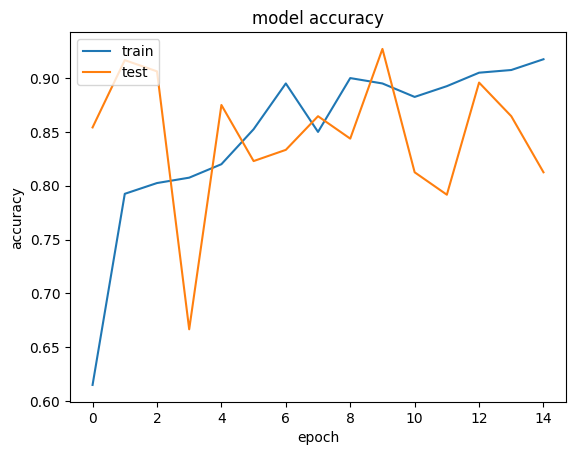

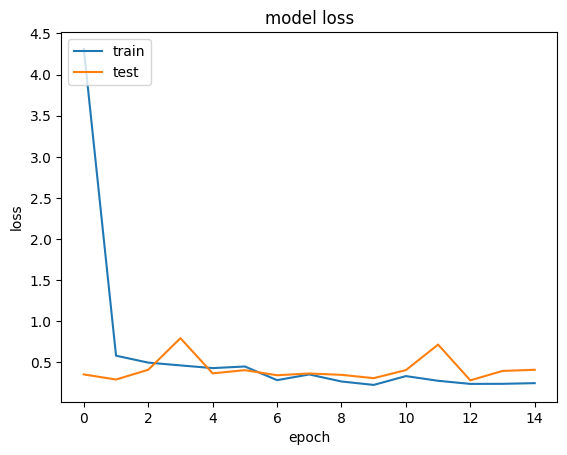

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

**exo**3

when changing the code to "train_datagen = ImageDataGenerator(rescale=1./255)
" the risk of overfitting got higher because the model train on fewer model , which mean the when the model is trained in a large data base it will perform better and would be a better to generalize with it

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First convolution layer
model.add(Conv2D(16, (3,3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(64, activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.5))

# Output layer (2 classes)
model.add(Dense(2, activation='softmax'))

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,250 (22.80 MB)

 Trainable params: 5,977,250 (22.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss ='binary_crossentropy',
optimizer ='rmsprop',

metrics =['accuracy'])
history=model.fit(train_generator,
 steps_per_epoch = nb_train_samples // batch_size,
 epochs = epochs, validation_data = validation_generator,
 validation_steps = nb_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 860ms/step - accuracy: 0.6300 - loss: 1.0151 - val_accuracy: 0.7708 - val_loss: 0.4918
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 870ms/step - accuracy: 0.7275 - loss: 0.5556 - val_accuracy: 0.8333 - val_loss: 0.4620
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8075 - loss: 0.4778 - val_accuracy: 0.8958 - val_loss: 0.2531
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7850 - loss: 0.4605 - val_accuracy: 0.8333 - val_loss: 0.3787
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8350 - loss: 0.4078 - val_accuracy: 0.8229 - val_loss: 0.3624
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8825 - loss: 0.3573 - val_accuracy: 0.7917 - val_loss: 0.4636
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8525 - loss: 0.3498 - val_accuracy: 0.8958 - val_loss: 0.2772
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 886ms/step - accuracy: 0.8675 - loss: 0.3616 - val_accuracy: 0.8438 - 

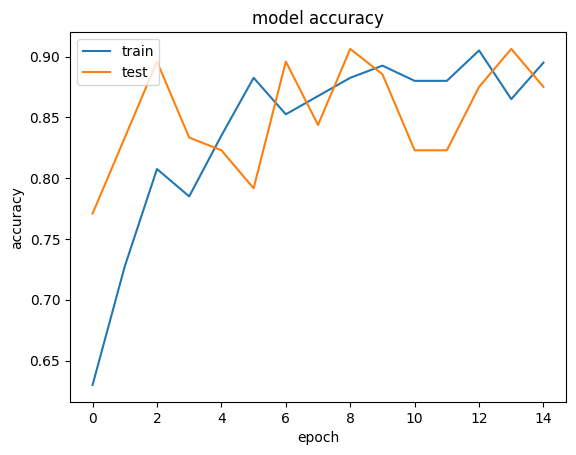

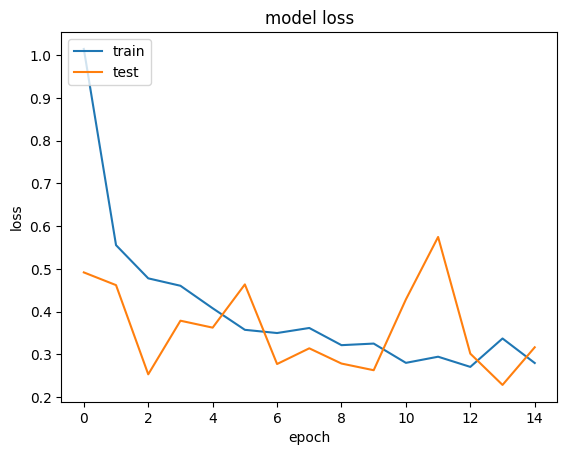

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Quelles sont les performances en classification de la nouvelle
CNN ?


The bew CNN architecture seem like it provieds better classification performance compares to original code if its more complexe and have more layers more calculating he can even avoide

---

overfitting

**exo** 5

In [ ]:
input_shape = (img_width, img_height, 1)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    color_mode='grayscale', #color mode to gray scale
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)
#w eneed this also for the genration code